> Projeto Desenvolve <br>
Programação Intermediária com Python <br>
Profa. Camila Laranjeira (mila@projetodesenvolve.com.br) <br>

# 3.9 - Visualização de Dados

## Exercícios
Vamos trabalhar com as mesmas bases de dados do exercício de Pandas. Aqui estão os links caso você queira baixar novamente, mas recomendo trabalhar com o `wc_formatado.csv` que exportamos na questão Q2 do exercício anterior.

* https://raw.githubusercontent.com/camilalaranjeira/python-intermediario/main/fifa-wc/matches_1930_2022.csv
* https://raw.githubusercontent.com/camilalaranjeira/python-intermediario/main/fifa-wc/matches_1991_2023.csv

Para relembrar, essas são as colunas do dataframe:
```
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   time_1             1312 non-null   string        
 1   time_2             1312 non-null   string        
 2   gols_1             1312 non-null   int64         
 3   gols_2             1312 non-null   int64         
 4   data               1312 non-null   datetime64[ns]
 5   ano                1312 non-null   int64         
 6   país_sede          1312 non-null   string        
 7   comparecimento     1312 non-null   int64         
 8   resultado          1312 non-null   string        
 9   rodada             1312 non-null   category      
 10  gols_1_detalhes    970 non-null    string        
 11  gols_2_detalhes    771 non-null    string        
 12  gols_1_contra      57 non-null     string        
 13  gols_2_contra      30 non-null     string        
 14  gols_1_penalti     170 non-null    string        
 15  gols_2_penalti     119 non-null    string        
 16  cartao_vermelho_1  59 non-null     string        
 17  cartao_vermelho_2  65 non-null     string        
 18  cartao_amarelo_1   834 non-null    string        
 19  cartao_amarelo_2   857 non-null    string        
 20  copa               1312 non-null   string 
```

#### Q1.
Realize todos os imports necessários para executar as três bibliotecas de visualização que conhecemos:
* Matplotlib (lembre-se do comando mágico)
* Seaborn
* Plotly

Para cada uma delas, altere o tema padrão de visualização. 

In [5]:
# =========================
# IMPORTS
# =========================

import pandas as pd
import numpy as np

# matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# seaborn
import seaborn as sns

# plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio


# =========================
# TEMAS
# =========================

plt.style.use('ggplot')

sns.set_theme(style='darkgrid')

pio.templates.default = 'plotly_dark'


# =========================
# CARREGAR DATASET
# =========================

wc = pd.read_csv(
    'https://raw.githubusercontent.com/camilalaranjeira/python-intermediario/main/fifa-wc/matches_1930_2022.csv'
)

# =========================
# RENOMEAR COLUNAS
# =========================

wc = wc.rename(columns={
    'home_team': 'time_1',
    'away_team': 'time_2',
    'home_score': 'gols_1',
    'away_score': 'gols_2',
    'Attendance': 'comparecimento',
    'Round': 'rodada',
    'Host': 'pais_sede',
    'Date': 'data',
    'Year': 'ano'
})

# =========================
# CONVERTER DATA
# =========================

wc['data'] = pd.to_datetime(wc['data'])

# =========================
# VISUALIZAR
# =========================

print(wc.head())


      time_1    time_2  gols_1  home_xg  home_penalty  gols_2  away_xg  \
0  Argentina    France       3      3.3           4.0       3      2.2   
1    Croatia   Morocco       2      0.7           NaN       1      1.2   
2     France   Morocco       2      2.0           NaN       0      0.9   
3  Argentina   Croatia       3      2.3           NaN       0      0.5   
4    Morocco  Portugal       1      1.4           NaN       0      0.9   

   away_penalty      home_manager  home_captain  ...  \
0           2.0    Lionel Scaloni  Lionel Messi  ...   
1           NaN      Zlatko Dalić   Luka Modrić  ...   
2           NaN  Didier Deschamps   Hugo Lloris  ...   
3           NaN    Lionel Scaloni  Lionel Messi  ...   
4           NaN   Hoalid Regragui  Romain Saïss  ...   

  home_penalty_shootout_miss_long  \
0                             NaN   
1                             NaN   
2                             NaN   
3                             NaN   
4                             NaN

#### Q2.
Sobre os dados de copa do mundo, qual a distribuição de público presente nos jogos? Isso pode ser respondido com um histograma com os dados da coluna `comparecimento`.  

Lembre-se que alguns jogos estavam com público 0 incorretamente, que tal remover essas ocorrências para não atrapalhar sua visualzação?

Você deve implementar essa visualização nas três bibliotecas que vimos:
* Matplotlib
* Seaborn
* Plotly

Garanta que o gráfico tenha pelo menos os atributos de título e rótulos de dimensão.

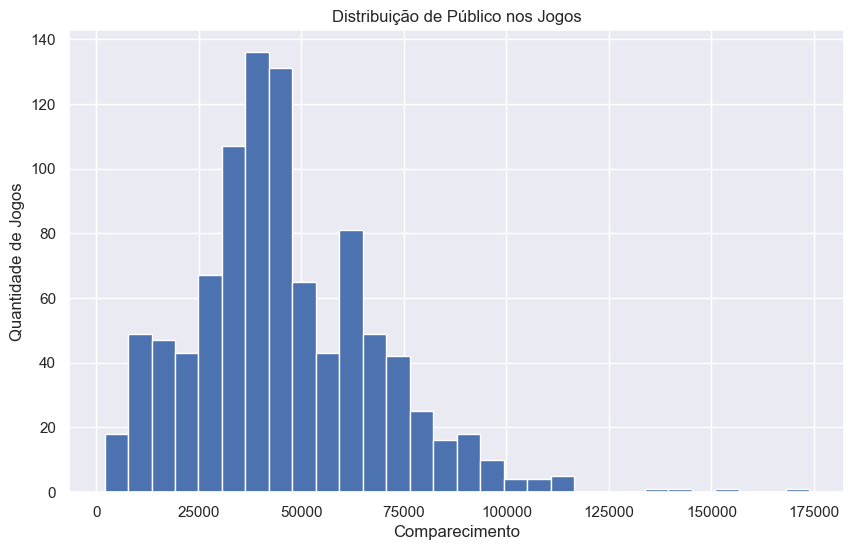

In [7]:
# remover valores inválidos
wc_publico = wc[wc['comparecimento'].notna()]

wc_publico = wc_publico[
    wc_publico['comparecimento'] > 0
]

# gráfico matplotlib
plt.figure(figsize=(10,6))

plt.hist(
    wc_publico['comparecimento'],
    bins=30
)

plt.title('Distribuição de Público nos Jogos')

plt.xlabel('Comparecimento')

plt.ylabel('Quantidade de Jogos')

plt.show()

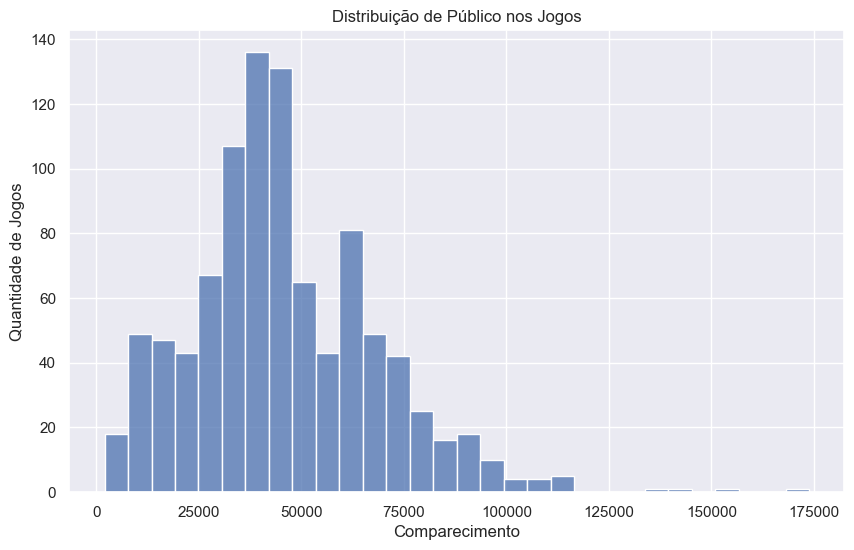

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=wc_publico,
    x='comparecimento',
    bins=30
)

plt.title('Distribuição de Público nos Jogos')

plt.xlabel('Comparecimento')

plt.ylabel('Quantidade de Jogos')

plt.show()

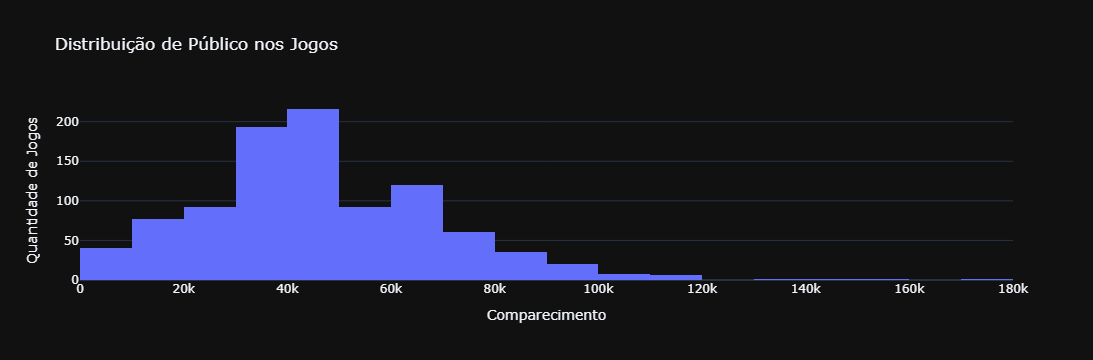

In [10]:
fig = px.histogram(
    wc_publico,
    x='comparecimento',
    nbins=30,
    title='Distribuição de Público nos Jogos'
)

fig.update_layout(
    xaxis_title='Comparecimento',
    yaxis_title='Quantidade de Jogos'
)

fig.show()

#### Q3.

Apresente um gráfico de dispersão (scatter) dos atributos `gols_1` e `gols_2`. Isso representa a relação entre gols feitos e gols tomados por jogo. Há alguma relação interessante entre esses atributos?

Para facilitar a visualização dos dados (já que tem muitos placares repetidos), aplique uma leve distorção aos dados para que cada ponto esteja deslocado aleatoriamente de seu valor original. Código apresentado a seguir
```python
gols = wc[['gols_1', 'gols_2']] * np.random.random((len(wc),2))
```

Você deve implementar essa visualização nas três bibliotecas que vimos:
* Matplotlib
* Seaborn
* Plotly

Garanta que o gráfico tenha pelo menos os atributos de título e rótulos de dimensão.

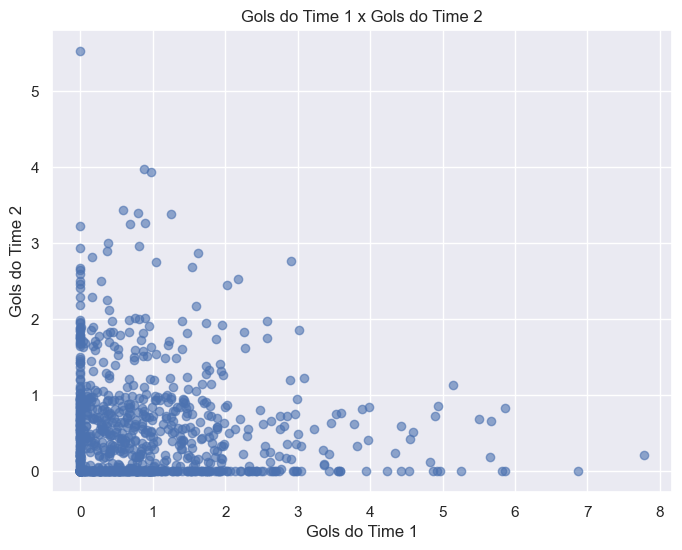

In [13]:
ols = wc[['gols_1', 'gols_2']] * np.random.random((len(wc),2))

plt.figure(figsize=(8,6))

plt.scatter(
    gols['gols_1'],
    gols['gols_2'],
    alpha=0.6
)

plt.title('Gols do Time 1 x Gols do Time 2')
plt.xlabel('Gols do Time 1')
plt.ylabel('Gols do Time 2')

plt.show()

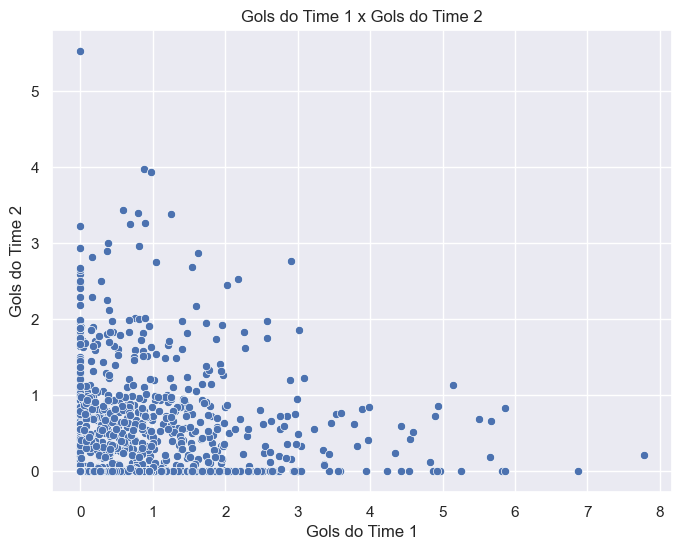

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=gols['gols_1'],
    y=gols['gols_2']
)

plt.title('Gols do Time 1 x Gols do Time 2')
plt.xlabel('Gols do Time 1')
plt.ylabel('Gols do Time 2')

plt.show()

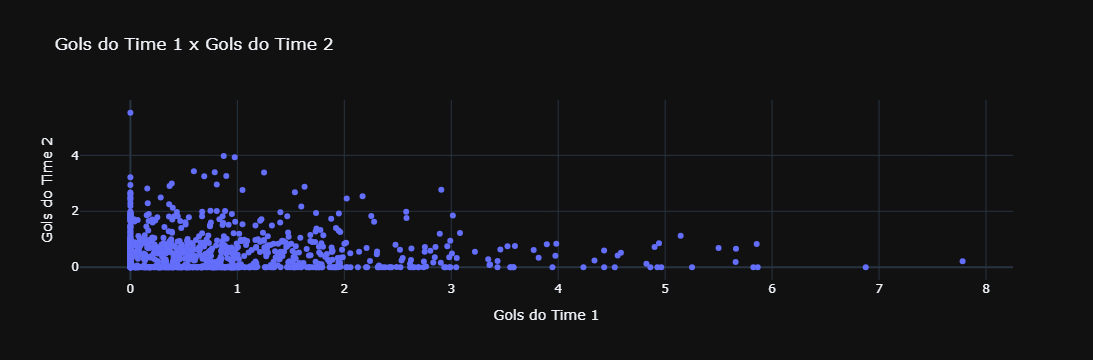

In [15]:
fig = px.scatter(
    gols,
    x='gols_1',
    y='gols_2',
    title='Gols do Time 1 x Gols do Time 2'
)

fig.update_layout(
    xaxis_title='Gols do Time 1',
    yaxis_title='Gols do Time 2'
)

fig.show()

#### Q4.

Apresente um gráfico de barras com o top 10 países que mais participaram de copas do mundo, onde no eixo x devem estar o nome dos países e no eixo y a contagem de participações. Você deve separar a contagem de participações em copas femininas e masculinas, empilhando as barras de cada informação.

No exemplo de barras empilhadas da galeria do matplotlib, imagine que a parte azul são as participações do país em copas masculinas, e em laranja as participações femininas:
* https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_stacked.html

Você deve implementar essa visualização nas três bibliotecas que vimos:
* Matplotlib
* Seaborn
* Plotly

Garanta que o gráfico tenha pelo menos os atributos:
* título
* rótulos de dimensão.
* legenda

In [18]:
times = pd.concat([wc['time_1'], wc['time_2']])

participacoes = times.value_counts()

top10 = participacoes.head(10)

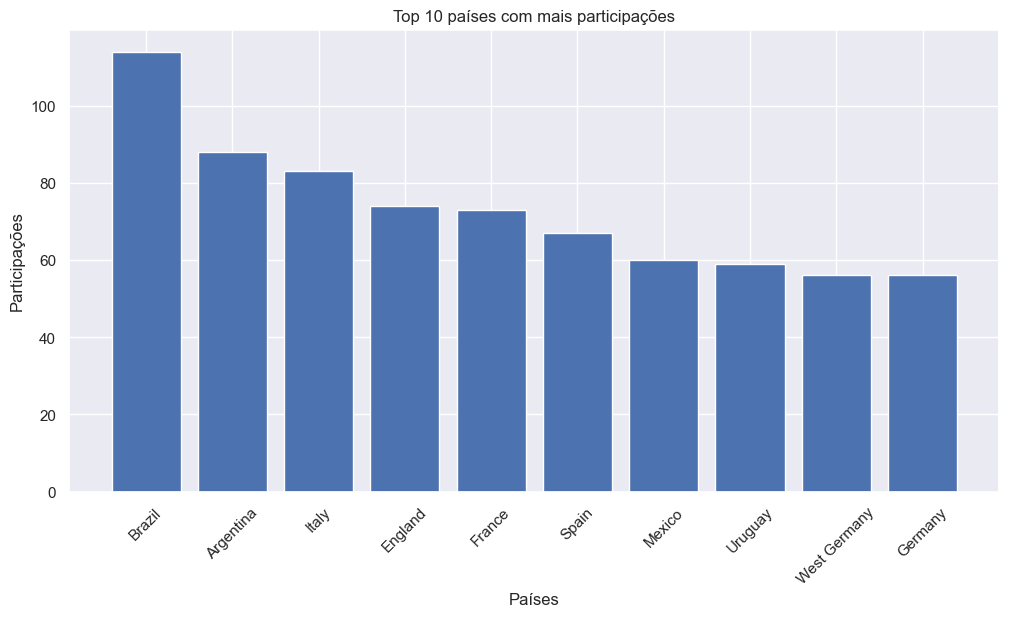

In [19]:
plt.figure(figsize=(12,6))

plt.bar(top10.index, top10.values)

plt.title('Top 10 países com mais participações')
plt.xlabel('Países')
plt.ylabel('Participações')

plt.xticks(rotation=45)

plt.show()

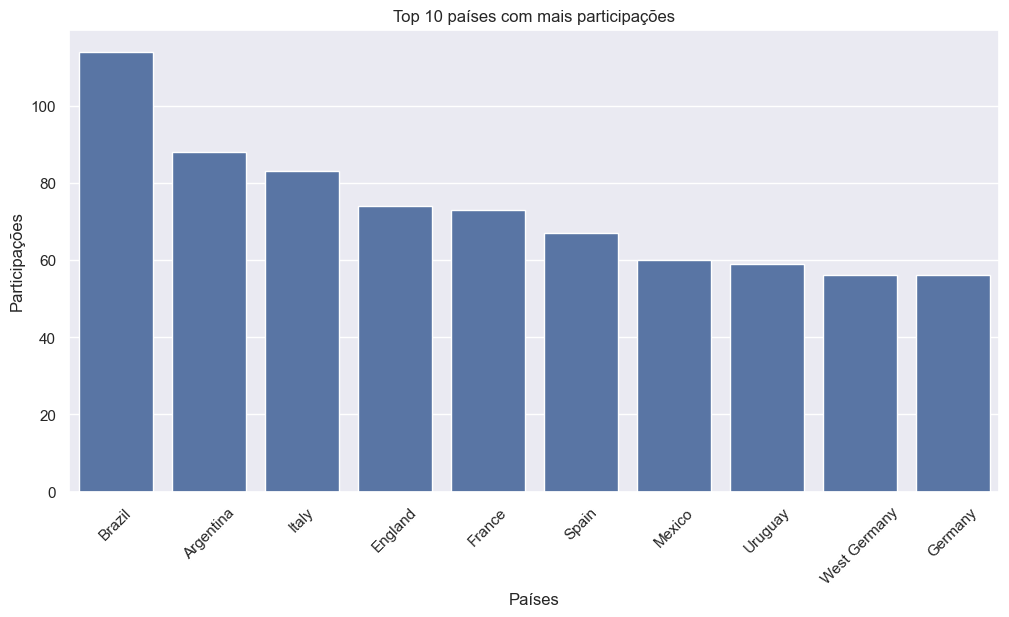

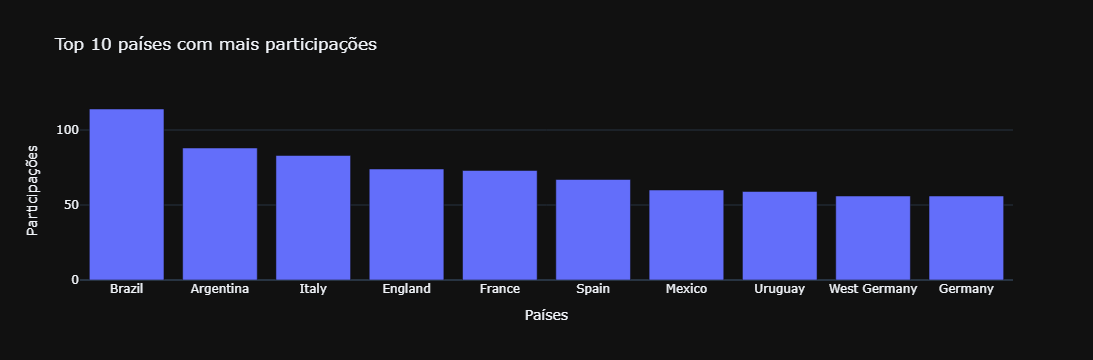

In [21]:
# =======================
# SEABORN
# =======================
plt.figure(figsize=(12,6))

sns.barplot(x=top10.index, y=top10.values)

plt.title('Top 10 países com mais participações')
plt.xlabel('Países')
plt.ylabel('Participações')

plt.xticks(rotation=45)

plt.show()


# =======================
# PLOTLY
# =======================

fig = px.bar(
    x=top10.index,
    y=top10.values,
    title='Top 10 países com mais participações'
)

fig.update_layout(
    xaxis_title='Países',
    yaxis_title='Participações'
)

fig.show()

#### Q5.

Vamos fazer um compilado com as estatísticas históricas de copas do mundo!

Com a biblioteca de sua preferência você deve criar 4 subplots organizados em um grid de 2 linhas e 2 colunas. Eles devem conter os seguintes gráficos:
* Linha 1, coluna 1: Gráfico de barras com a quantidade de jogos que aconteceram por ano
* Linha 1, coluna 2: Gráfico de área (referências a seguir) com o total de gols por ano, separando as informações de `gols_1` e `gols_2` para distinguir gols em casa e do time visitante.
* Linha 2, coluna 1: Gráfico de área com o total de cartões por ano, separando as informações de cartões amarelos e cartões vermelhos, mas agregando cartões do time 1 ou time 2. Ou seja, uma área com `cartao_amarelo_1 + cartao_amarelo_2` e outra área com `cartao_vermelho_1 + cartao_vermelho_2`.
* Linha 2, coluna 2: Gráfico de barras com o total de gols contra por ano, somando `gols_contra_1` e `gols_contra_2`.

Referências sobre gráfico de área
* Matplotlib: https://matplotlib.org/stable/gallery/lines_bars_and_markers/stackplot_demo.html#sphx-glr-gallery-lines-bars-and-markers-stackplot-demo-py
* Pandas + Matplotlib: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.area.html
* Seaborn: https://seaborn.pydata.org/generated/seaborn.objects.Area.html
* Plotly: https://plotly.com/python/filled-area-plots/

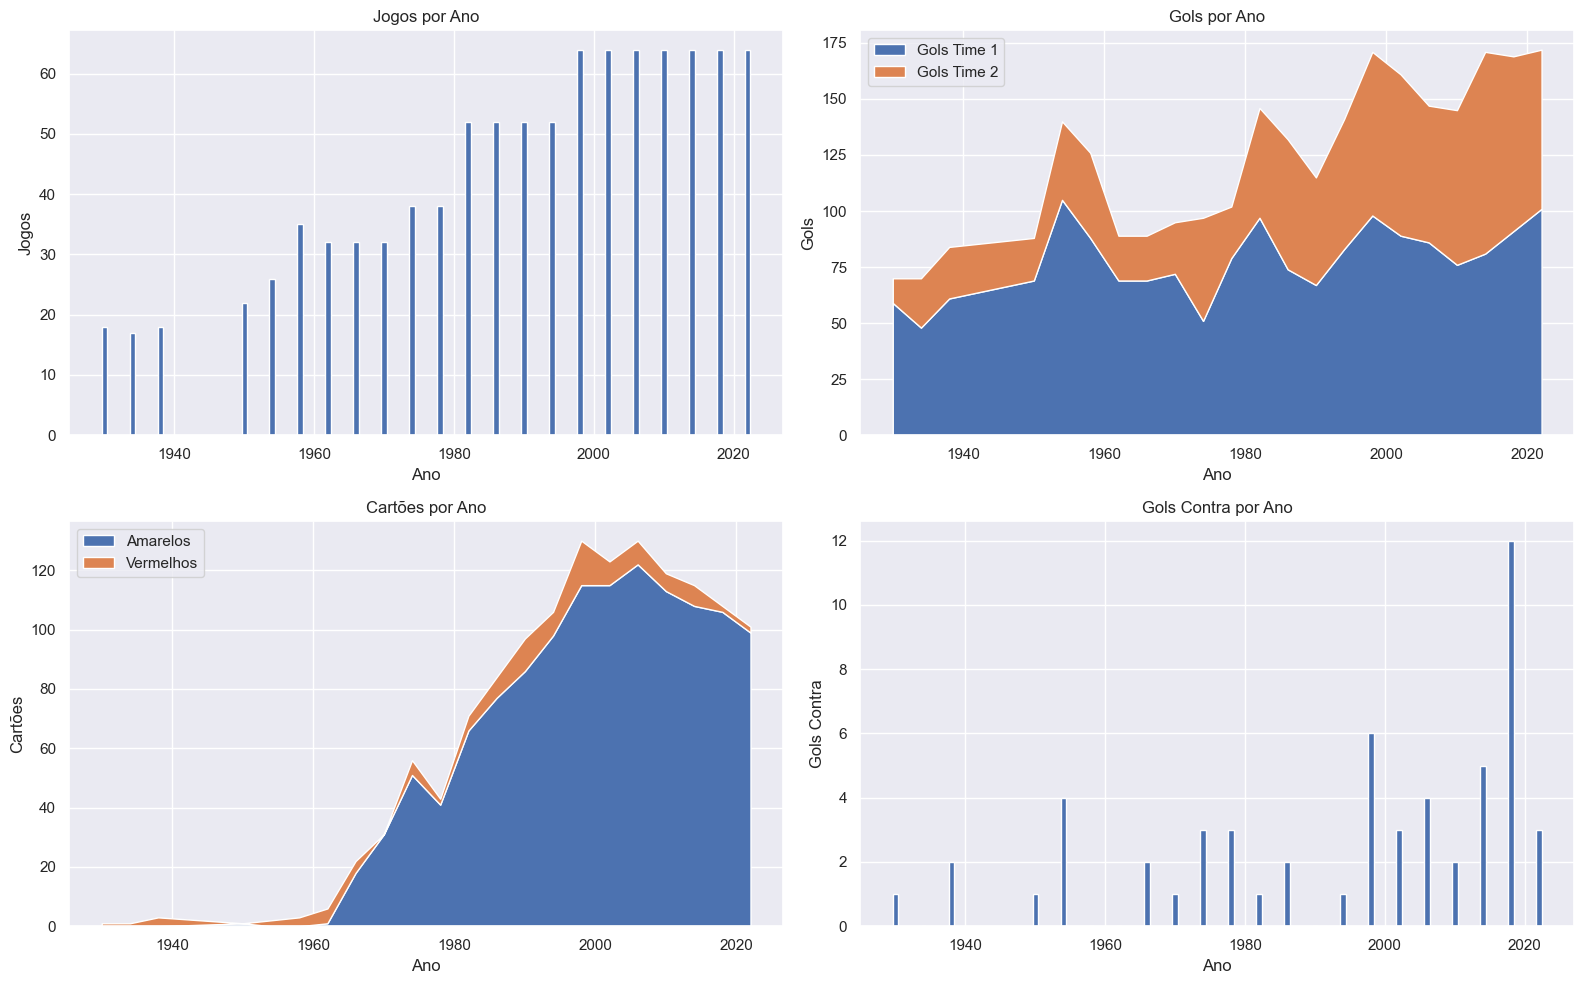

In [22]:
import matplotlib.pyplot as plt

# =========================
# PREPARAÇÃO DOS DADOS
# =========================

# jogos por ano
jogos_ano = wc.groupby('ano').size()

# gols por ano
gols_ano = wc.groupby('ano')[['gols_1', 'gols_2']].sum()

# cartões amarelos (aproximação: não-nulos)
amarelos = (
    wc['home_yellow_card_long'].notna().astype(int) +
    wc['away_yellow_card_long'].notna().astype(int)
)

# cartões vermelhos
vermelhos = (
    wc['home_red_card'].notna().astype(int) +
    wc['away_red_card'].notna().astype(int)
)

cartoes_ano = pd.DataFrame({
    'ano': wc['ano'],
    'amarelos': amarelos,
    'vermelhos': vermelhos
}).groupby('ano').sum()

# gols contra (aproximação via NaN não funciona bem, então usamos coluna existente se houver)
if 'home_own_goal' in wc.columns:
    gols_contra = (
        wc['home_own_goal'].notna().astype(int) +
        wc['away_own_goal'].notna().astype(int)
    )
    gols_contra_ano = pd.DataFrame({
        'ano': wc['ano'],
        'gols_contra': gols_contra
    }).groupby('ano').sum()
else:
    gols_contra_ano = jogos_ano * 0


# =========================
# SUBPLOTS
# =========================

fig, axes = plt.subplots(2, 2, figsize=(16,10))

# -------------------------
# 1 - jogos por ano
# -------------------------
axes[0,0].bar(jogos_ano.index, jogos_ano.values)
axes[0,0].set_title('Jogos por Ano')
axes[0,0].set_xlabel('Ano')
axes[0,0].set_ylabel('Jogos')

# -------------------------
# 2 - gols por ano (área)
# -------------------------
axes[0,1].stackplot(
    gols_ano.index,
    gols_ano['gols_1'],
    gols_ano['gols_2'],
    labels=['Gols Time 1', 'Gols Time 2']
)

axes[0,1].set_title('Gols por Ano')
axes[0,1].set_xlabel('Ano')
axes[0,1].set_ylabel('Gols')
axes[0,1].legend()

# -------------------------
# 3 - cartões por ano (área)
# -------------------------
axes[1,0].stackplot(
    cartoes_ano.index,
    cartoes_ano['amarelos'],
    cartoes_ano['vermelhos'],
    labels=['Amarelos', 'Vermelhos']
)

axes[1,0].set_title('Cartões por Ano')
axes[1,0].set_xlabel('Ano')
axes[1,0].set_ylabel('Cartões')
axes[1,0].legend()

# -------------------------
# 4 - gols contra
# -------------------------
axes[1,1].bar(
    gols_contra_ano.index,
    gols_contra_ano.iloc[:,0]
)

axes[1,1].set_title('Gols Contra por Ano')
axes[1,1].set_xlabel('Ano')
axes[1,1].set_ylabel('Gols Contra')

plt.tight_layout()
plt.show()